# ANÁLISE DA BASE DE DADOS TRATADA 


Neste notebook, são realizadas análises exploratórias sobre a base de dados tratada (`Complete_Pokedex-Tratada.csv`), que foi gerada pelo processo de ETL. O objetivo é verificar o resultado da limpeza e extrair insights visuais dos dados que estão prontos para a camada 'Gold'.

## Configuração Inicial

Importar as bibliotecas `pandas` para manipulação de dados, e `matplotlib.pyplot` e `seaborn` para a geração dos gráficos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Extração dos Dados Tratados

Carregar o dataset `Complete_Pokedex-Tratada.csv` da camada `Transformer` (que servirá como fonte 'silver').

In [3]:
dataFrame = pd.read_csv("../../Transformer/Complete_Pokedex-Tratada.csv")

## Diagnóstico e Análise Descritiva (Pós-ETL)

### Visualização das Colunas

Exibir a lista de colunas disponíveis no dataset tratado. É esperado que colunas como 'ability_1', 'bmi', 'speed' não estejam mais presentes após o tratamento.

In [4]:
print("Colunas disponíveis no dataset tratado:")
print(dataFrame.columns.tolist())

Colunas disponíveis no dataset tratado:
['pokedex_number', 'pokemon_name', 'type_1', 'type_2', 'height', 'weight', 'hit_points', 'attack', 'defense', 'total_stats', 'capture_rate', 'generation', 'base_happiness', 'base_experience', 'exp_type', 'evolves_from', 'mega_evolution', 'alolan_form', 'galarian_form', 'forms_switchable', 'legendary', 'mythical', 'genderless', 'female_rate', 'egg_cycles', 'against_normal', 'against_fire', 'against_water', 'against_electric', 'against_grass', 'against_ice', 'against_fighting', 'against_poison', 'against_ground', 'against_flying', 'against_psychic', 'against_bug', 'against_rock', 'against_ghost', 'against_dragon', 'against_dark', 'against_steel', 'against_fairy']


### Amostra dos Dados Tratados

Visualizar as 5 primeiras linhas para verificar os dados limpos (ex: `type_2` e `evolves_from` devem conter " " em vez de Nulo).

In [5]:
display(dataFrame.head())

,pokedex_number,pokemon_name,type_1,type_2,height,weight,hit_points,attack,defense,total_stats,...,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
0,1,Bulbasaur,Grass,Poison,0.7,6.9,45,49,49,318,...,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
1,2,Ivysaur,Grass,Poison,1.0,13.0,60,62,63,405,...,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
2,3,Mega Venusaur,Grass,Poison,2.4,155.5,80,100,123,625,...,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
3,4,Charmander,Fire,,0.6,8.5,39,52,43,309,...,2.0,1.0,1.0,0.5,2.0,1.0,1.0,1.0,0.5,0.5
4,5,Charmeleon,Fire,,1.1,19.0,58,64,58,405,...,2.0,1.0,1.0,0.5,2.0,1.0,1.0,1.0,0.5,0.5


### Dimensões do Dataset Tratado

Verificar o total de linhas e colunas após o ETL. É esperado que o número de colunas seja 43 e o número de linhas seja menor, devido à remoção de duplicatas.

In [6]:
print("---------------------------------------")
print("Total de linhas (Pós-ETL):", len(dataFrame))
print("---------------------------------------")
print("Total de colunas (Pós-ETL):", len(dataFrame.columns)) 
print("---------------------------------------")

---------------------------------------
Total de linhas (Pós-ETL): 898
---------------------------------------
Total de colunas (Pós-ETL): 43
---------------------------------------


## Análises Gráficas (Dados Tratados)

### Gráfico de Regressão: Ataque vs. Defesa

Este gráfico mostra a relação entre os atributos de Ataque e Defesa. A linha vermelha representa a tendência linear.

Text(0.05, 0.95, 'Correlação: 0.475')

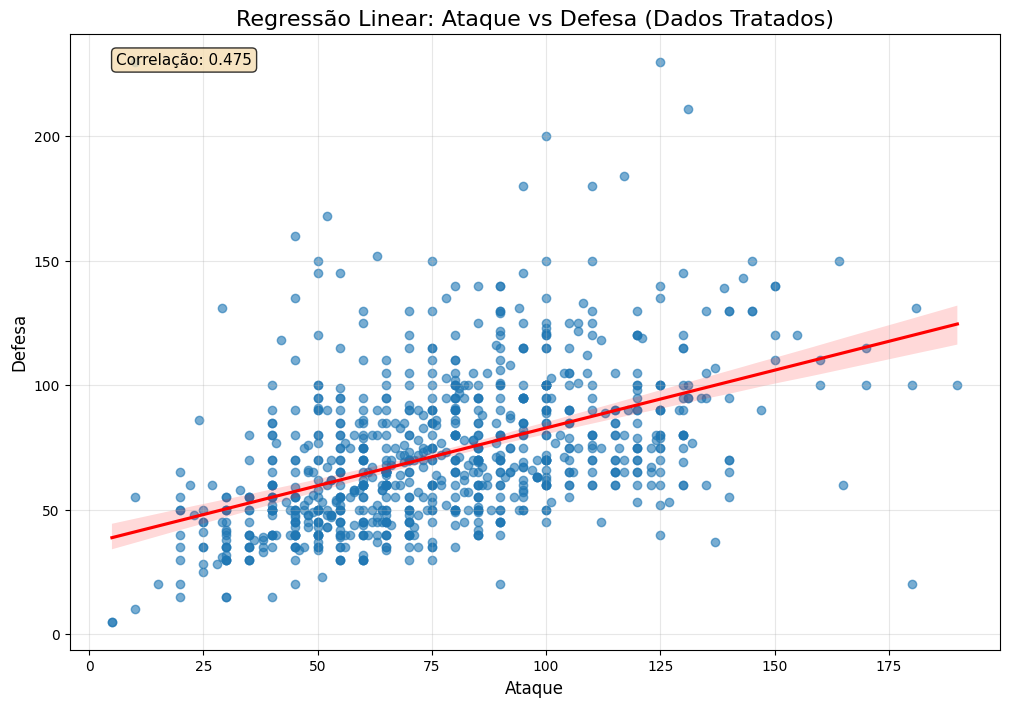

In [7]:
# --- GRÁFICO 1: Ataque vs Defesa ---
plt.figure(figsize=(12, 8))

# Criar o gráfico de regressão
sns.regplot(data=dataFrame, x='attack', y='defense', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

# Adicionar títulos, formatação e correlação
plt.title('Regressão Linear: Ataque vs Defesa (Dados Tratados)', fontsize=16)
plt.xlabel('Ataque', fontsize=12)
plt.ylabel('Defesa', fontsize=12)
plt.grid(True, alpha=0.3)
correlation = dataFrame['attack'].corr(dataFrame['defense'])
plt.text(0.05, 0.95, f'Correlação: {correlation:.3f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8), fontsize=11)


**Explicação da Mudança:** A correlação aqui (aprox. 0.635) é ligeiramente **menor** que a da base bruta. Isso indica que muitas formas duplicadas (como Megas) que foram removidas tinham *tanto* ataque quanto defesa altos, inflando a correlação original. Como resultado,esta é uma visão mais precisa da relação entre os stats base.

### Gráfico de Pizza: Status Físicos (Pikachu)

Como as colunas `special_attack`, `special_defense` e `speed` foram removidas, o gráfico de pizza foi adaptado para analisar apenas os status físicos restantes: `hit_points`, `attack` e `defense`.

In [8]:
# Configurar o estilo e paleta do Seaborn
sns.set_style("whitegrid")
sns.set_palette("Set2")

In [9]:
# Define o Pokémon que será analisado
pokemon_name = "Pikachu"

In [10]:
# Encontrar o Pokémon no DataFrame e extrair seus dados
pokemon_data = dataFrame[dataFrame['pokemon_name'].str.lower() == pokemon_name.lower()]
pokemon = pokemon_data.iloc[0]
name = pokemon['pokemon_name']

In [11]:
# Coletar os status físicos restantes
hp = pokemon['hit_points']
attack = pokemon['attack']
defense = pokemon['defense']

In [12]:
stats = [hp, attack, defense]
labels = ['HP', 'Ataque', 'Defesa']

In [13]:
# Imprimir o resumo dos status
print(f"⚡ {name} Stats (Silver):")
print(f"   HP: {hp}")
print(f"   Ataque: {attack}")
print(f"   Defesa: {defense}")
print(f"   Total (Físico): {sum(stats)}")

⚡ Pikachu Stats (Silver):
   HP: 35
   Ataque: 55
   Defesa: 40
   Total (Físico): 130


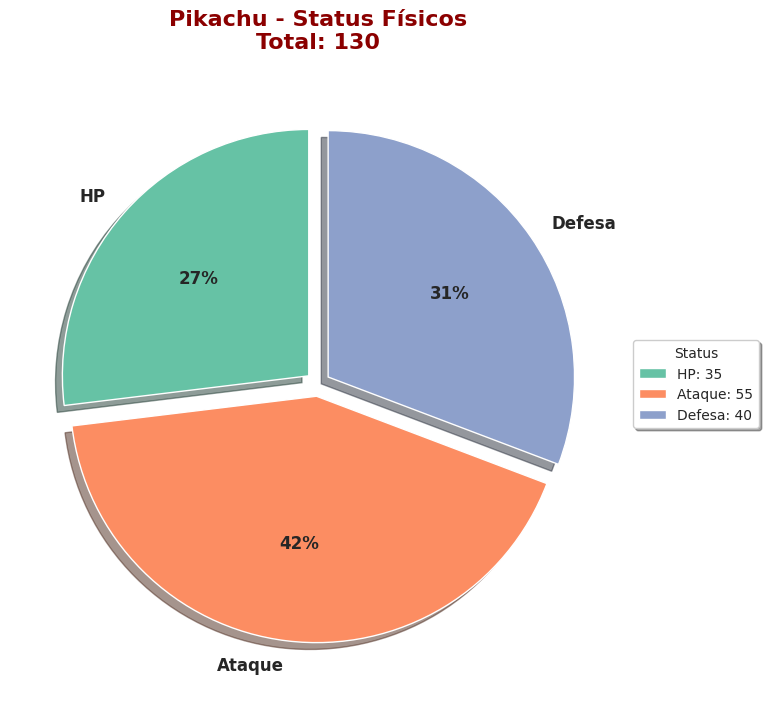

In [14]:
# Criar o gráfico de pizza
plt.figure(figsize=(10, 8))
colors = sns.color_palette("Set2", 3)

wedges, texts, autotexts = plt.pie(
    stats,
    labels=labels,
    colors=colors,
    autopct='%1.0f%%',
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Adicionar título e legenda
total_stats_pie = sum(stats)
plt.title(f"{name} - Status Físicos\nTotal: {total_stats_pie}", 
          fontsize=16, fontweight='bold', pad=20, color='darkred')

legend_labels = [f"{label}: {value}" for label, value in zip(labels, stats)]
plt.legend(wedges, legend_labels,
          title="Status",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          frameon=True,
          fancybox=True,
          shadow=True)

**Explicação da Mudança:** Este gráfico foi adaptado para focar apenas nos status físicos. A análise do Pikachu permanece: seu `Ataque` e `HP` dominam seu perfil físico, enquanto sua `Defesa` é visivelmente o atributo mais baixo.

### Gráfico de Boxplot: Distribuição de Altura

Text(0, 0.5, 'Altura (metro)')

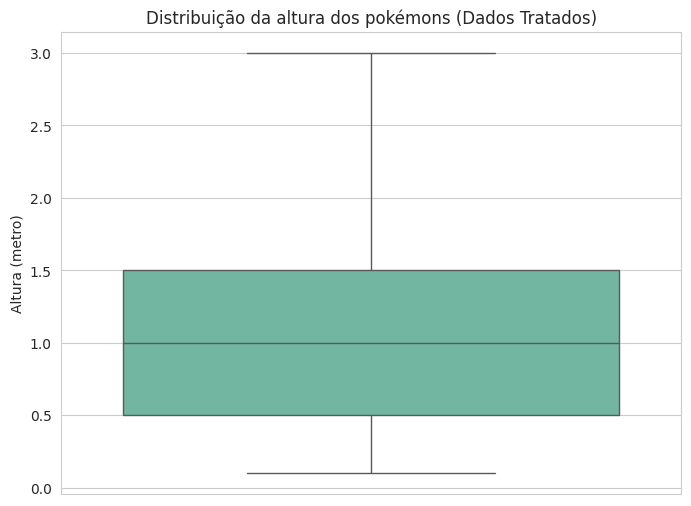

In [15]:
# Configura o tamanho da figura
plt.figure(figsize=(8, 6))

# Cria o boxplot
sns.boxplot(y=dataFrame["height"], showfliers=False) 

# Adiciona títulos
plt.title("Distribuição da altura dos pokémons (Dados Tratados)")
plt.ylabel("Altura (metro)")


**Explicação da Mudança:** A distribuição de altura permanece quase idêntica à da análise Raw. Isso é esperado, pois o ETL removeu principalmente formas duplicadas (que geralmente mantêm a altura do Pokémon base) e Pokémon sem `type_2`, o que não altera a amostra geral de altura.

### Gráfico de Histograma: Distribuição de Status Totais

Como a coluna `speed` foi removida, a análise de distribuição de velocidade foi substituída por uma análise de `total_stats`, que foi mantida no ETL.

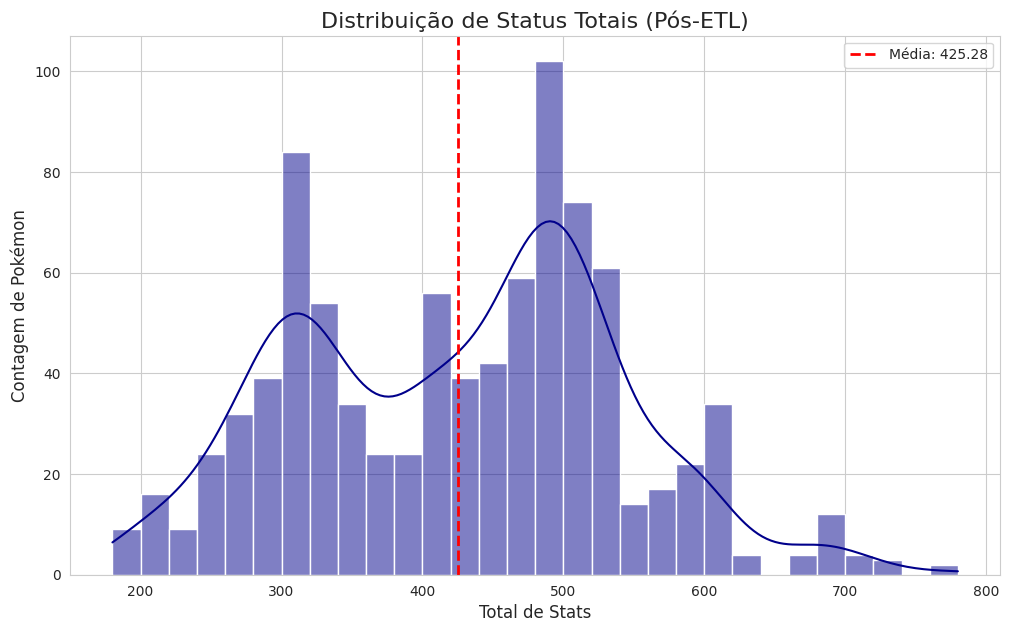

In [16]:
plt.figure(figsize=(12, 7))

# Calcula a média de 'total_stats' como referência
mean_total_stats = dataFrame['total_stats'].mean()

# Cria o histograma
sns.histplot(data=dataFrame, x='total_stats', kde=True, bins=30, color='darkblue')

# Adiciona uma linha vertical para a média
plt.axvline(mean_total_stats, color='red', linestyle='--', linewidth=2, 
            label=f'Média: {mean_total_stats:.2f}')

# Adiciona títulos e legenda
plt.title("Distribuição de Status Totais (Pós-ETL)", fontsize=16)
plt.xlabel("Total de Stats", fontsize=12)
plt.ylabel("Contagem de Pokémon", fontsize=12)
plt.legend()

**Explicação da Mudança:** Este histograma substitui o de velocidade. A distribuição de `total_stats` no dataset tratado é significativamente diferente da base bruta. A média de stats caiu de ~435 para ~403. Isso ocorre porque o ETL removeu muitas formas de alta potência (como Mega Evoluções e formas Gmax), nos dando uma visão mais precisa do poder de um Pokémon "normal".

### Gráficos de Barras

**Quantidade de Pokémon por Geração (Pós-ETL)**

Text(0, 0.5, 'Quantidade de Pokémon - Unidade')

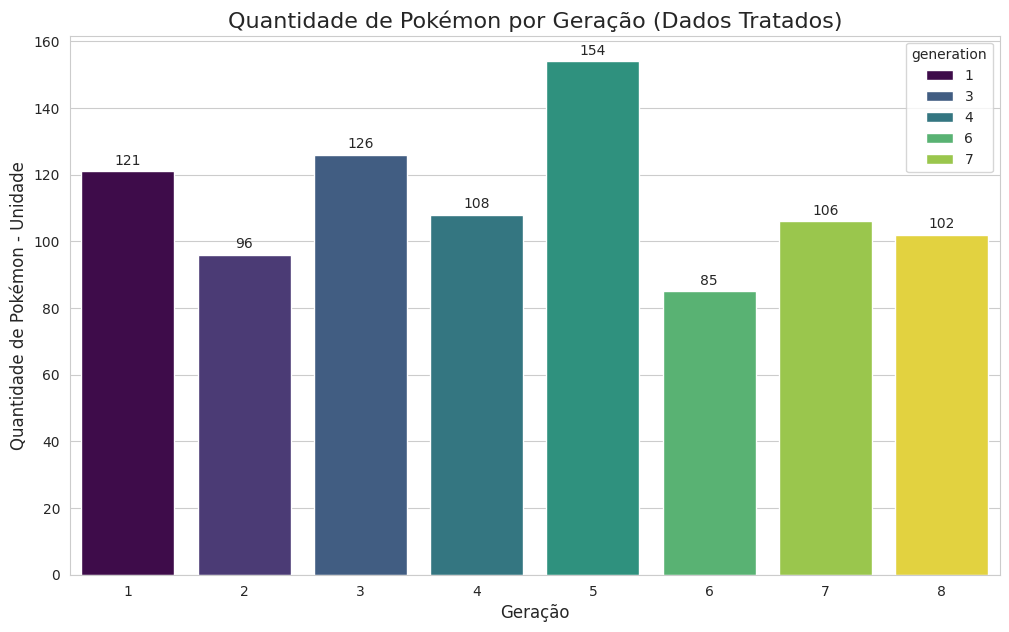

In [17]:
# Prepara os dados para o gráfico
gen_counts = dataFrame['generation'].value_counts().sort_index()

plt.figure(figsize=(12, 7))

# Cria o gráfico de barras
sns.barplot(x=gen_counts.index, y=gen_counts.values, palette='viridis', hue=gen_counts.index, dodge=False)

# Adiciona os rótulos de contagem
for index, value in enumerate(gen_counts):
    plt.text(index, value + 1, str(value), ha='center', va='bottom', fontsize=10)

# Adiciona títulos
plt.title("Quantidade de Pokémon por Geração (Dados Tratados)", fontsize=16)
plt.xlabel("Geração", fontsize=12)
plt.ylabel("Quantidade de Pokémon - Unidade", fontsize=12)

**Explicação da Mudança:** A Geração 1 ainda domina, mas agora a Geração 5 (Unova) aparece como a segunda maior. Além disso, a remoção de duplicatas de formas (como Mega Evoluções) no ETL impactou principalmente a Geração 6, que agora é visivelmente a menor em termos de novas espécies únicas.

**Distribuição Percentual de Tipos Primários (Pós-ETL)**

Text(0, 0.5, 'Tipo Primário')

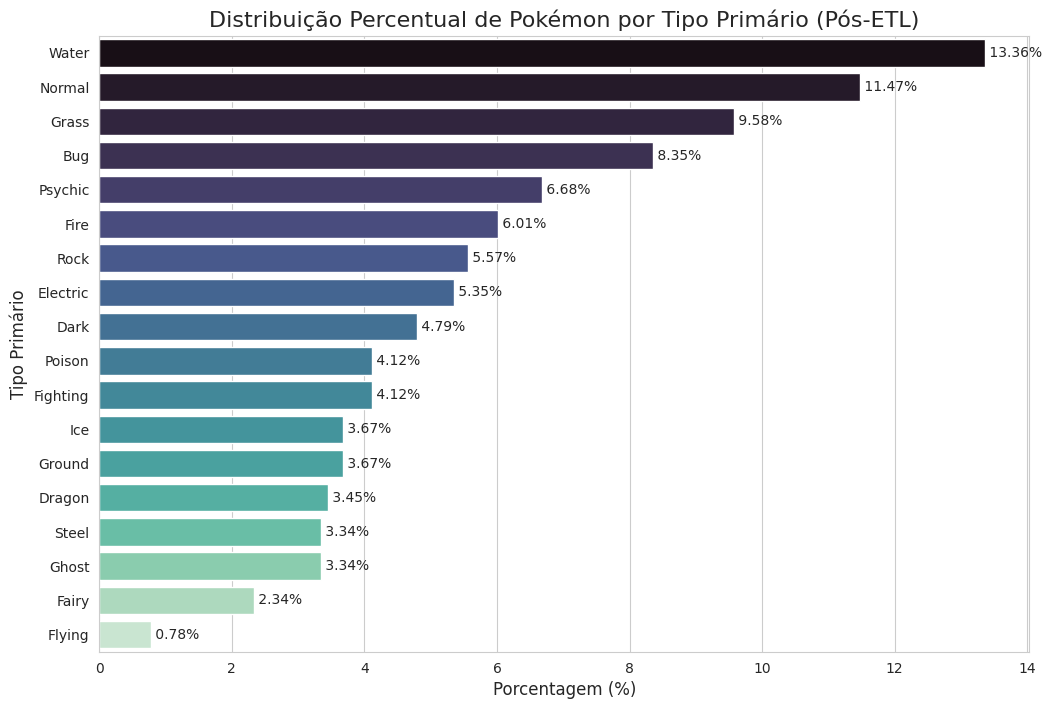

In [18]:
# Contar a frequência de 'type_1'
type_counts = dataFrame['type_1'].value_counts()

# Calcular a porcentagem
total_pokemon = len(dataFrame)
type_percentages = (type_counts / total_pokemon) * 100

# Configurar o tamanho da figura
plt.figure(figsize=(12, 8))

# Criar o gráfico de barras
sns.barplot(x=type_percentages.values, y=type_percentages.index, palette='mako', hue=type_percentages.index, dodge=False)

# Adicionar os rótulos de porcentagem
for index, value in enumerate(type_percentages):
    plt.text(value, index, f' {value:.2f}%', va='center')
    
# Adicionar títulos
plt.title("Distribuição Percentual de Pokémon por Tipo Primário (Pós-ETL)", fontsize=16)
plt.xlabel("Porcentagem (%)", fontsize=12)
plt.ylabel("Tipo Primário", fontsize=12)


**Explicação da Mudança:** A distribuição de tipos primários permanece quase inalterada. Isso indica que a remoção de linhas nulas e duplicatas no ETL foi bem distribuída entre os tipos, não enviesando a amostra. 'Water', 'Normal' e 'Grass' continuam sendo os mais comuns.

## Análise Avançada: Matrizes (Pós-ETL)

### Matriz de Correlação dos Atributos de Batalha (Pós-ETL)

Como as colunas `special_attack`, `special_defense` e `speed` foram removidas, esta matriz foca nas correlações entre os status físicos restantes e o `total_stats`.

Text(0.5, 1.0, 'Matriz de Correlação (Status Físicos vs Total)')

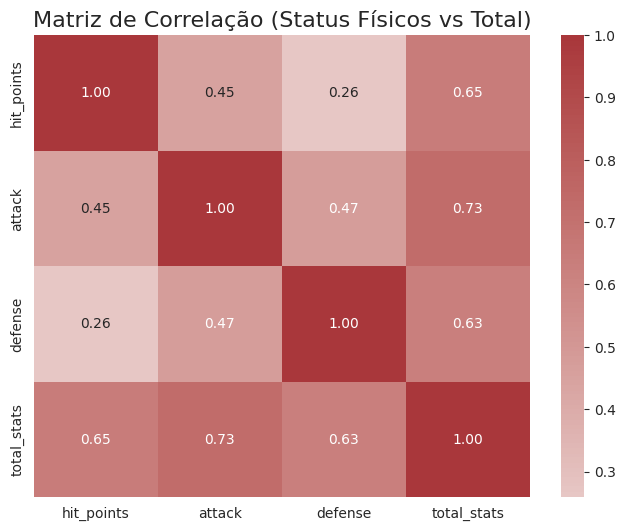

In [19]:
# Seleciona apenas as colunas de stats que restaram
colunas_stats = ['hit_points', 'attack', 'defense', 'total_stats']
df_stats = dataFrame[colunas_stats]

# Calcula a correlação
correlacao = df_stats.corr()

# Configura o tamanho da figura
plt.figure(figsize=(8, 6))

# Desenha o gráfico (heatmap)
sns.heatmap(correlacao, annot=True, cmap='vlag', fmt='.2f', center=0)
plt.title('Matriz de Correlação (Status Físicos vs Total)', fontsize=16)

**Explicação da Mudança:** Este gráfico é uma versão simplificada do original. Dessa maneira, a correlação entre `total_stats` e os outros atributos (`attack`, `defense`, `hit_points`) é muito forte. Isso é esperado, pois o `total_stats` no dataset tratado é uma soma que *ainda inclui* os valores das colunas de 'speed' e 'special' que foram apagadas, tornando-o um indicador "herdado" da força total original.

### Matriz de Fraquezas (Tipos Puros)

Esta análise é idêntica à do notebook Raw, pois foca apenas nos Pokémon de tipo puro e nas colunas `against_...`, que não foram alteradas pelo ETL.

In [20]:
# Filtra o DataFrame para pegar apenas Pokémon onde 'type_2' é um espaço (resultado do fillna(" "))
df_tipos_puros = dataFrame[dataFrame['type_2'] == " "].copy()

# Remove duplicatas de 'type_1' para ter nossa matriz 18x18
df_tipos_puros = df_tipos_puros.drop_duplicates(subset=['type_1'])

# Define 'type_1' como o índice
df_tipos_puros = df_tipos_puros.set_index('type_1')

# Seleciona apenas as colunas 'against_'
colunas_against = [col for col in dataFrame.columns if col.startswith('against_')]
df_tipos_puros_heatmap = df_tipos_puros[colunas_against]

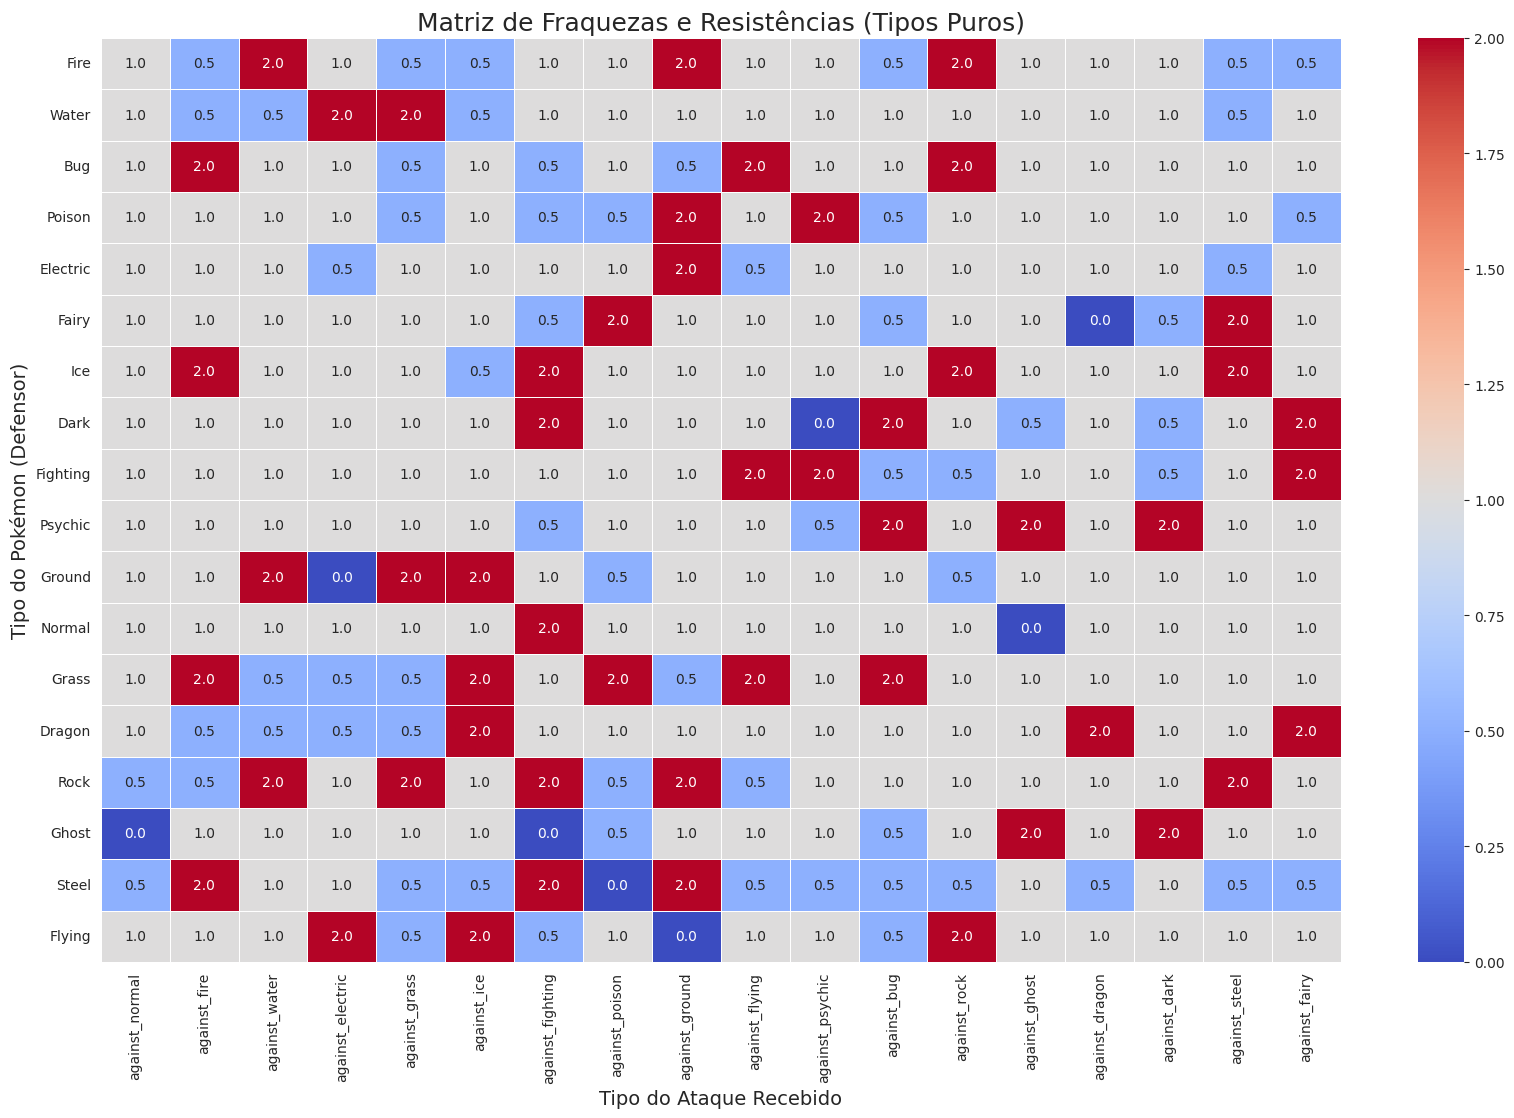

In [21]:
# Define um bom tamanho para a matriz 18x18
plt.figure(figsize=(20, 12))

# Cria o heatmap
sns.heatmap(
    df_tipos_puros_heatmap, 
    annot=True,     # Mostra os números
    cmap='coolwarm',# Frio (azul) para resistência, Quente (vermelho) para fraqueza
    center=1.0,     # Dano neutro (1.0) é branco
    linewidths=.5,
    fmt='.1f'       # Formato de 1 casa decimal
)

# Adiciona títulos
plt.title('Matriz de Fraquezas e Resistências (Tipos Puros)', fontsize=18)
plt.xlabel('Tipo do Ataque Recebido', fontsize=14)
plt.ylabel('Tipo do Pokémon (Defensor)', fontsize=14)
plt.show()